# Cecilia Quiroz Hidalgo
# 10/09/2026

### Importación de datos

In [1]:
import pandas as pd

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("College.csv")
df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### Exploración de datos

In [5]:
df.columns

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate'],
      dtype='object')

In [6]:
df = df.drop("Unnamed: 0", axis=1)

In [7]:
df["Private"].unique()

array(['Yes', 'No'], dtype=object)

### Cambio de variable categórica a numérica

In [8]:
df['Private'] = df['Private'].replace({"Yes": 1, "No": 0})

C:\Users\ceciq\AppData\Local\Temp\ipykernel_9872\3012417132.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Private'] = df['Private'].replace({"Yes": 1, "No": 0})


In [9]:
df["Private"].unique()

array([1, 0])

In [10]:
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### Regresión lineal

In [33]:
x = df[['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend']]
x = sm.add_constant(x)
y = df['Grad.Rate']

In [12]:
ols = sm.OLS(y, x)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Grad.Rate   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     38.27
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           4.98e-90
Time:                        12:46:48   Log-Likelihood:                -3071.0
No. Observations:                 777   AIC:                             6178.
Df Residuals:                     759   BIC:                             6262.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          33.8737      4.848      6.987      0.000      24.356      43.391
Private         3.3814      1.697      1.993      0.047       0.051       6.712
Apps            0.0013      0.000      2.939      0.003       0.000       0.002
Accept         -0.0007      0.001     -0.807      0.420      -0.002       0.001
Enroll          0.0022      0.002      0.936      0.350      -0.002       0.007
Top10perc       0.0549      0.072      0.765      0.445      -0.086       0.196
Top25perc       0.1351      0.055      2.458      0.014       0.027       0.243
F.Undergrad    -0.0005      0.000     -1.176      0.240      -0.001       0.000
P.Undergrad    -0.0015      0.000     -3.802      0.000      -0.002      -0.001
Outstate        0.0010      0.000      4.359      0.000       0.001       0.001
Room.Board      0.0019      0.001      3.240      0.001       0.001       0.003
Books          -0.0022      0.003     -0.761      0.447      -0.008       0.004
Personal       -0.0017      0.001     -2.161      0.031      -0.003      -0.000
PhD             0.0873      0.057      1.536      0.125      -0.024       0.199
Terminal       -0.0747      0.062     -1.199      0.231      -0.197       0.048
S.F.Ratio       0.0758      0.159      0.476      0.634      -0.237       0.389
perc.alumni     0.2793      0.049      5.680      0.000       0.183       0.376
Expend         -0.0005      0.000     -2.961      0.003      -0.001      -0.000
==============================================================================
Omnibus:                       36.176   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               96.746
Skew:                           0.163   Prob(JB):                     9.81e-22
Kurtosis:                       4.698   Cond. No.                     1.81e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
x = df[['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend']].values
y = df['Grad.Rate']

In [14]:
lr = LinearRegression()

In [15]:
#x_v = np.reshape(x,[-1,1])
x_v = x

In [16]:
X = x_v

In [17]:
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
lr.intercept_

np.float64(33.87367161394407)

In [19]:
lr.coef_

array([ 3.38137582e+00,  1.29841620e-03, -6.96123912e-04,  2.15927837e-03,
        5.48964394e-02,  1.35128822e-01, -4.71221055e-04, -1.48364258e-03,
        1.01744534e-03,  1.91434107e-03, -2.22046571e-03, -1.66353477e-03,
        8.72827139e-02, -7.47022673e-02,  7.58222052e-02,  2.79334292e-01,
       -4.56463007e-04])

In [20]:
lr.predict(X)

array([ 57.26434471,  63.13235809,  67.26555232,  77.02325712,
        51.97784386,  65.73546213,  70.0402887 ,  77.36462412,
        73.13544992,  58.6893626 ,  80.85814477,  82.79438342,
        66.35982449,  76.80196887,  55.37420224,  59.64625011,
        95.20262068,  59.06477589,  54.86642835,  53.24941029,
        55.56369719,  58.58409088,  65.15484344,  50.75271607,
        65.49318588,  48.7131857 ,  76.26781668,  57.75780099,
        65.54110313,  77.48382806,  67.23919415,  72.30121689,
        59.21370153,  60.37623843,  65.75327084,  64.4018626 ,
        86.1293099 ,  90.90982167,  58.25755674,  71.53084199,
        73.14095865,  65.44020513,  57.73584791,  63.39125856,
        71.25228445,  48.32017733,  59.65975827,  75.1884258 ,
        71.77791083,  63.43586131,  61.32299292,  61.22576347,
        53.00632952,  50.58020894,  78.05048828,  68.60290543,
        60.72846565,  54.02181728,  64.45258521,  91.88896656,
        91.61664372,  58.62971588,  65.12579798,  64.99

In [21]:
R2 = lr.score(X,y)
R2

0.46154054497464536

### Pruebas para problemas de errores

In [22]:
residuos = y - lr.predict(X)
residuos

0       2.735655
1      -7.132358
2     -13.265552
3     -18.023257
4     -36.977844
         ...    
772   -11.604046
773    14.226760
774   -15.208392
775     6.066454
776    34.800256
Name: Grad.Rate, Length: 777, dtype: float64

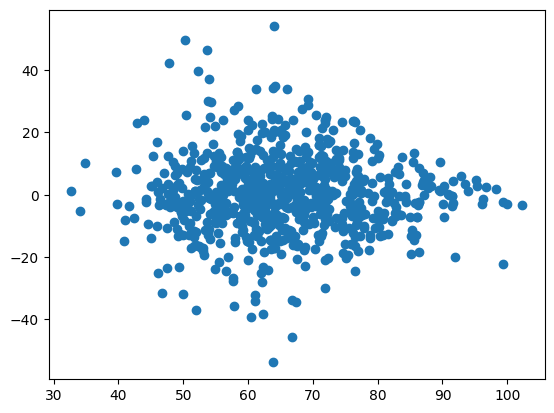

In [23]:
y_hat = lr.predict(X)
plt.scatter(lr.predict(X), residuos)
plt.show()

### Interpretación

- **No linealidad:** Si existe este problema pero de forma leve, no hay una curva tan clara
- **Heterocedasticidad:** Podemos ver a simple vista que en algunos puntos los puntos están muy juntos, en otros están mas dispersos, esto ya directamente nos dice que no hay varianza constante.
- **Correlación:** La nube de residuos se mantiene centrada alrededor de cero en todo el rango de valores, lo que nos indica que prácticamente no hay correlación. 

### Valores atípicos

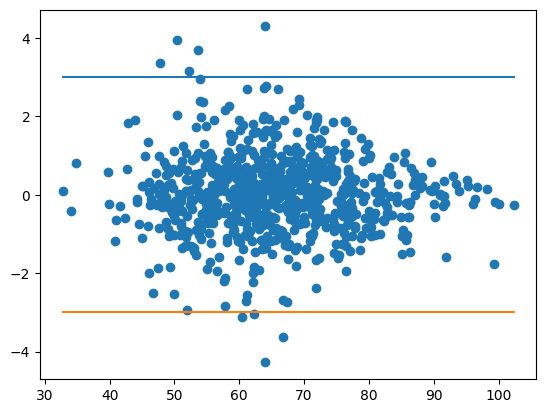

In [24]:
va = residuos / np.std(residuos)
va
plt.figure()
plt.scatter(y_hat, va)
plt.plot([min(y_hat), max(y_hat)], [3, 3])
plt.plot([min(y_hat), max(y_hat)], [-3, -3])

Aunque son pocos, si hay algunos errores que son outliers, se resuelve eliminándolos. 

### Puntos palanca

In [25]:
n = len(x)

In [26]:
x_bar = np.mean(x)
x_bar

np.float64(2175.1347338935575)

In [27]:
x_dis = x - x_bar
x_dis = x_dis**2

In [28]:
x_var = x - x_bar
x_var = x_dis**2
x_var = np.sum(x_dis)
x_var

np.float64(204995832909.8441)

In [29]:
hi = 1/n + (x_dis/x_var)
hi

array([[0.00131006, 0.0012883 , 0.00129134, ..., 0.0013097 , 0.00130983,
        0.0014025 ],
       [0.00131006, 0.001287  , 0.00128731, ..., 0.00130982, 0.00130974,
        0.00162727],
       [0.00131006, 0.00128972, 0.00129267, ..., 0.00130981, 0.00130945,
        0.00149692],
       ...,
       [0.00131006, 0.00128703, 0.00128733, ..., 0.00130978, 0.00130966,
        0.00147138],
       [0.00131006, 0.00164193, 0.00128738, ..., 0.00130996, 0.00130905,
        0.00840944],
       [0.00131006, 0.00129023, 0.0012875 , ..., 0.0013097 , 0.00130949,
        0.00131357]], shape=(777, 17))

In [30]:
p = X.shape[1] - 1
ss = (p+1)/n

punto_palanca = hi >= ss
df[punto_palanca]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


No se encontro que hubiera algún punto palanca en el modelo. 

### Colinealidad

**Private:**

In [36]:
cols_p = x.columns.drop("Private")
X_otras = x[cols_p]
y_j = x["Private"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_p = lr_aux.score(X_otras, y_j)

vif_p = 1 / (1 - r2_p)
print(vif_p)

2.731335619841144


Colinealidad baja.

**Apps:**

In [37]:
cols_ap = x.columns.drop("Apps")
X_otras = x[cols_ap]
y_j = x["Apps"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_ap = lr_aux.score(X_otras, y_j)

vif_ap = 1 / (1 - r2_ap)
print(vif_ap)

13.963106846854949


Colinealidad problemática, lo mejor sería eliminarla. 

**Accept:**

In [ ]:
cols_ac = x.columns.drop("Accept")
X_otras = x[cols_ac]
y_j = x["Accept"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_ac = lr_aux.score(X_otras, y_j)

vif_ac = 1 / (1 - r2_ac)
print(vif_ac)

21.362550778368597


Colinealidad problemática, se recomienda eliminarla. 

**Enroll:**

In [39]:
cols_en = x.columns.drop("Enroll")
X_otras = x[cols_en]
y_j = x["Enroll"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_en = lr_aux.score(X_otras, y_j)

vif_en = 1 / (1 - r2_en)
print(vif_en)

21.971429953036964


Colinealidad problemática, aquí ya se sospecha de un patrón donde las variables Apps, Accept y Enroll están relacionadas entre ellas ya que representan etapas consecutivas del mismo proceso de admisión. Como solución, se podría eliminar una o dos de estas variables.

In [40]:
df[['Apps', 'Accept', 'Enroll']].corr()

,Apps,Accept,Enroll
Apps,1.000000,0.943451,0.846822
Accept,0.943451,1.000000,0.911637
Enroll,0.846822,0.911637,1.000000


**Top10perc:**

In [41]:
cols_10 = x.columns.drop("Top10perc")
X_otras = x[cols_10]
y_j = x["Top10perc"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_10 = lr_aux.score(X_otras, y_j)

vif_10 = 1 / (1 - r2_10)
print(vif_10)

7.654596140480163


Colinealidad alta, se eliminará para solucionar también la alta colinealidad de 'Top25perc'

In [60]:
x = x.drop(columns=["Top10perc"])

**Top25perc:**

In [61]:
cols_25 = x.columns.drop("Top25perc")
X_otras = x[cols_25]
y_j = x["Top25perc"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_25 = lr_aux.score(X_otras, y_j)

vif_25 = 1 / (1 - r2_25)
print(vif_25)

1.9671060585163034


Colinealidad baja después de eliminar 'Top10perc'.

**F.Undergrad:**

In [43]:
cols_F = x.columns.drop("F.Undergrad")
X_otras = x[cols_F]
y_j = x["F.Undergrad"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_F = lr_aux.score(X_otras, y_j)

vif_F = 1 / (1 - r2_F)
print(vif_F)

18.058175272777365


Colinealidad muy alta, se hará un análisis para ver si está relacionada con las otras variables con colinealidad alta. 

In [54]:
df[['Apps', 'Accept', 'Enroll', 'F.Undergrad']].corr()

,Apps,Accept,Enroll,F.Undergrad
Apps,1.000000,0.943451,0.846822,0.814491
Accept,0.943451,1.000000,0.911637,0.874223
Enroll,0.846822,0.911637,1.000000,0.964640
F.Undergrad,0.814491,0.874223,0.964640,1.000000


Las 4 variables están fuertemente relacionadas entre sí, se eliminarán variables. 

In [57]:
x = x.drop(columns=["Accept", "F.Undergrad"])

Se checa el VIF de nuevo: 

In [58]:
cols_ap = x.columns.drop("Apps")
X_otras = x[cols_ap]
y_j = x["Apps"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_ap = lr_aux.score(X_otras, y_j)

vif_ap = 1 / (1 - r2_ap)
print(vif_ap)

4.607288069292512


In [59]:
cols_en = x.columns.drop("Enroll")
X_otras = x[cols_en]
y_j = x["Enroll"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_en = lr_aux.score(X_otras, y_j)

vif_en = 1 / (1 - r2_en)
print(vif_en)

4.951666642926008


**Colinealidad alta solucionada**

**P.Undergrad:**

In [44]:
cols_P = x.columns.drop("P.Undergrad")
X_otras = x[cols_P]
y_j = x["P.Undergrad"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_P = lr_aux.score(X_otras, y_j)

vif_P = 1 / (1 - r2_P)
print(vif_P)

1.6856374856770568


Colinealidad baja, no representa un problema. 

**Outstate:**

In [45]:
cols_O = x.columns.drop("Outstate")
X_otras = x[cols_O]
y_j = x["Outstate"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_O = lr_aux.score(X_otras, y_j)

vif_O = 1 / (1 - r2_O)
print(vif_O)

4.2126355550994266


Colinealidad moderada, no representa un gran problema para el modelo. 

**Room.Board:**

In [46]:
cols_RB = x.columns.drop("Room.Board")
X_otras = x[cols_RB]
y_j = x["Room.Board"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_RB = lr_aux.score(X_otras, y_j)

vif_RB = 1 / (1 - r2_RB)
print(vif_RB)

2.005441513975796


Colinealidad baja, no represenat un problema.

**Books:**

In [47]:
cols_B = x.columns.drop("Books")
X_otras = x[cols_B]
y_j = x["Books"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_B = lr_aux.score(X_otras, y_j)

vif_B = 1 / (1 - r2_B)
print(vif_B)

1.1079096044546735


Colinealidad baja, no es un problema. 

**Personal:**

In [48]:
cols_Pe = x.columns.drop("Personal")
X_otras = x[cols_Pe]
y_j = x["Personal"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_Pe = lr_aux.score(X_otras, y_j)

vif_Pe = 1 / (1 - r2_Pe)
print(vif_Pe)

1.2976045776604368


Colinealidad baja, no representa ningún problema.

**PhD:**

In [49]:
cols_Ph = x.columns.drop("PhD")
X_otras = x[cols_Ph]
y_j = x["PhD"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_Ph = lr_aux.score(X_otras, y_j)

vif_Ph = 1 / (1 - r2_Ph)
print(vif_Ph)

4.110406807433793


Colinealidad moderada, no representa un gran problema.

**Terminal:**

In [50]:
cols_T = x.columns.drop("Terminal")
X_otras = x[cols_T]
y_j = x["Terminal"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_T = lr_aux.score(X_otras, y_j)

vif_T = 1 / (1 - r2_T)
print(vif_T)

4.020949882823647


Colinealidad moderada, no es un problema. 

**S.F.Ratio:**

In [51]:
cols_SF = x.columns.drop("S.F.Ratio")
X_otras = x[cols_SF]
y_j = x["S.F.Ratio"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_SF = lr_aux.score(X_otras, y_j)

vif_SF = 1 / (1 - r2_SF)
print(vif_SF)

1.8996491430313431


Colinealidad baja, no genera problema para el modelo. 

**perc.alumni:**

In [52]:
cols_Pa = x.columns.drop("perc.alumni")
X_otras = x[cols_Pa]
y_j = x["perc.alumni"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_Pa = lr_aux.score(X_otras, y_j)

vif_Pa = 1 / (1 - r2_Pa)
print(vif_Pa)

1.7738480441979223


Colinealidad baja, no representa un problema. 

**Expend:**

In [53]:
cols_Ex = x.columns.drop("Expend")
X_otras = x[cols_Ex]
y_j = x["Expend"]

lr_aux = LinearRegression()
lr_aux.fit(X_otras, y_j)
r2_Ex = lr_aux.score(X_otras, y_j)

vif_Ex = 1 / (1 - r2_Ex)
print(vif_Ex)

3.0956297163717874


Colinealidad moderada, no hay problema. 

### Interacción

In [69]:
x['interaccion'] = x['Private'] * x['Outstate']

In [72]:
ols = sm.OLS(y, x)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Grad.Rate   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     43.09
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           5.52e-91
Time:                        15:15:36   Log-Likelihood:                -3072.6
No. Observations:                 777   AIC:                             6177.
Df Residuals:                     761   BIC:                             6252.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          32.9293      5.723      5.754      0.000      21.696      44.163
Private         3.7814      3.655      1.034      0.301      -3.394      10.957
Apps            0.0010      0.000      3.952      0.000       0.001       0.002
Enroll         -0.0007      0.001     -0.632      0.527      -0.003       0.001
Top25perc       0.1730      0.032      5.334      0.000       0.109       0.237
P.Undergrad    -0.0016      0.000     -4.319      0.000      -0.002      -0.001
Outstate        0.0010      0.000      2.235      0.026       0.000       0.002
Room.Board      0.0019      0.001      3.174      0.002       0.001       0.003
Books          -0.0021      0.003     -0.729      0.466      -0.008       0.004
Personal       -0.0017      0.001     -2.200      0.028      -0.003      -0.000
PhD             0.0931      0.056      1.653      0.099      -0.017       0.204
Terminal       -0.0873      0.062     -1.410      0.159      -0.209       0.034
S.F.Ratio       0.0704      0.161      0.438      0.662      -0.245       0.386
perc.alumni     0.2900      0.049      5.916      0.000       0.194       0.386
Expend         -0.0004      0.000     -2.553      0.011      -0.001   -8.58e-05
interaccion -2.903e-05      0.000     -0.062      0.951      -0.001       0.001
==============================================================================
Omnibus:                       34.779   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               87.433
Skew:                           0.180   Prob(JB):                     1.03e-19
Kurtosis:                       4.603   Cond. No.                     2.62e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.62e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Se incluyó un término de interacción entre Private y Outstate para evaluar si el efecto de la colegiatura para foráneos sobre la tasa de graduación 
depende de si la universidad es privada. El resultado arrojó un p-value de 0.951, muy por encima del umbral de significancia de 0.05, por lo que se concluye que esta 
interacción no es estadísticamente significativa.